## Business Understanding

We want to predict which train stations are most vulnerable to which meteorological phenomena in Finland. Our goal is to cluster train stations by the amount of delay associated with a weather phenomena. The study is done for educational purposes and there is no real-world motivation. The assumption is that weather causes delays and that some stations are more prone to delays caused or associated different weather phenomena such as rain or freezing temperatures. Only stations where a train has actually stopped are used. The plan is to first extract the data from Kaggle, understand the data, prepare the data, model and evaluate. 

---

## Data Understanding

The data is pulled from Kaggle using Python. The data consists of Finnish railway operational data paired with meteorological observations for delay prediction. The data is filled with records containing a single timetable event `Arrival / Departure` of long-distance VR-trains at stations as well as the weather observation from the nearest weather station at the time of the stop.

[Link to Data (www.kaggle.com)](https://www.kaggle.com/datasets/viniborin/finland-integrated-train-weather-dataset-fi-tw)

Period: 2018–2025 | Records: ~48 million | Columns: up to 125 | Sources: Digitraffic + Finnish Meteorological Institute

> **Note:** All exploration below is based on a single month of data. This sample is used only to understand the data's structure and quality and the full date range will be used for modeling.

In [41]:
import kagglehub
import pandas as pd

#download the dataset from Kaggle using the kagglehub library
path = kagglehub.dataset_download("viniborin/finland-integrated-train-weather-dataset-fi-tw")

In [42]:
from pathlib import Path

#import the dataset
file = Path(path) / "matched_data_flat_2025_10.parquet"
metadata_file = Path(path) / "metadata_train_stations.csv"

print(path)

#read the parquet file into a pandas dataframe
df = pd.read_parquet(file)

#List the available columns in the dataset
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
    print(f"{i:>3}. {col:<45} {dtype}")

/Users/blendigraicevci/.cache/kagglehub/datasets/viniborin/finland-integrated-train-weather-dataset-fi-tw/versions/3
  1. trainNumber                                   int64
  2. departureDate                                 str
  3. operatorUICCode                               int64
  4. operatorShortCode                             str
  5. trainType                                     str
  6. trainCategory                                 str
  7. commuterLineID                                float64
  8. runningCurrently                              bool
  9. cancelled                                     bool
 10. version                                       int64
 11. timetableType                                 str
 12. timetableAcceptanceDate                       str
 13. stationName                                   str
 14. stationShortCode                              str
 15. stationUICCode                                int64
 16. countryCode                            

In total we have 123 columns of data in this dataset. We have all the necessary features to correctly associate station delays with weather phenomena. We have different weather data for the time of the stop and also rolling-window aggregates 12h/24h/72h from the time of the stop. We will be using only the instantaneous weather observations for this study. In addition we have necessary information for training such as the delayed time, causes for delay, station data and train data. The next step is to extract and prepare only the necessary data needed to train the model.

In [43]:
df.describe(include='all')

,trainNumber,departureDate,operatorUICCode,operatorShortCode,trainType,trainCategory,commuterLineID,runningCurrently,cancelled,version,...,Precipitation amount (12h mean),Precipitation amount (12h cumulative),Precipitation amount (24h mean),Precipitation amount (24h cumulative),Precipitation amount (72h mean),Precipitation amount (72h cumulative),estimateSource,liveEstimateTime,unknownDelay,unknownTrack
count,537724.000000,537724,537724.000000,537724,537724,537724,0.0,537724,537724,5.377240e+05,...,537724.000000,537724.000000,537724.000000,537724.000000,537724.000000,537724.000000,31276,31253,6687,390
unique,NaN,31,NaN,6,8,1,NaN,2,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,20886,2,2
top,NaN,2025-10-17,NaN,vr,IC,Long-distance,NaN,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,LIIKE_AUTOMATIC,2025-10-03T18:17:00.000Z,False,True
freq,NaN,19226,NaN,536846,367444,537724,NaN,537540,536382,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28973,6,6418,376
mean,324.708620,NaN,16.441762,NaN,NaN,NaN,NaN,NaN,NaN,2.924115e+11,...,0.085474,1.996041,0.086157,4.043114,0.078725,11.097153,NaN,NaN,NaN,NaN
std,1059.410042,NaN,181.100603,NaN,NaN,NaN,NaN,NaN,NaN,7.827937e+07,...,0.172391,4.027823,0.146912,6.882475,0.103923,14.614362,NaN,NaN,NaN,NaN
min,1.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.922838e+11,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,35.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.923508e+11,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,70.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.924087e+11,...,0.000000,0.000000,0.010000,0.400000,0.030000,4.200000,NaN,NaN,NaN,NaN
75%,269.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.924697e+11,...,0.090000,2.000000,0.110000,5.400000,0.130000,18.200000,NaN,NaN,NaN,NaN


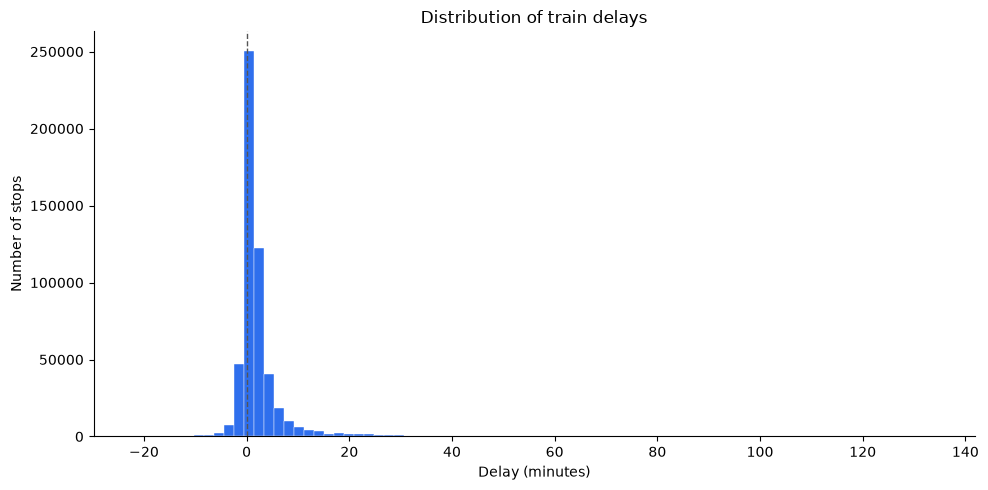

In [44]:
import matplotlib.pyplot as plt

#plot the distribution of train delays, clipped to the 0.1-99.9th percentile to avoid extreme outliers squashing the view
delay = df['differenceInMinutes'].dropna()
lower, upper = delay.quantile([0.001, 0.999])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(delay.clip(lower, upper), bins=80, color='#2F6FED', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='#555555', linewidth=1, linestyle='--')
ax.set_title('Distribution of train delays')
ax.set_xlabel('Delay (minutes)')
ax.set_ylabel('Number of stops')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

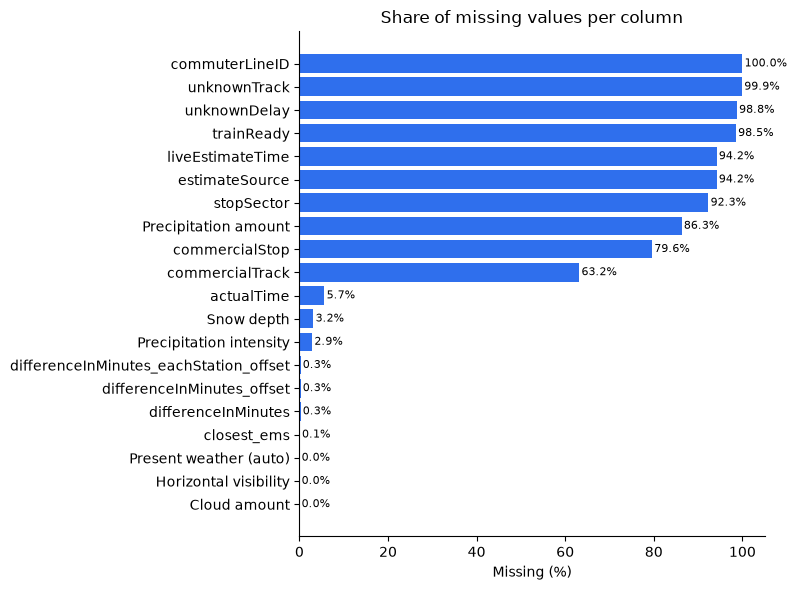

In [45]:
#data quality: share of missing values per column, only columns with at least one missing value
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(missing_pct))))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color='#2F6FED')
for y, v in enumerate(missing_pct.values[::-1]):
    ax.text(v + 0.5, y, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 105)
ax.set_xlabel('Missing (%)')
ax.set_title('Share of missing values per column')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

We see the share of missing values per column is unusually high for Precipitation Amount, which is a feature we need for training. We need to make sure that a NaN value means that no precipitation was recorded at the time of the stop. Also features we need such as snow depth and precipitation intensity both have over 4% of missing data. 

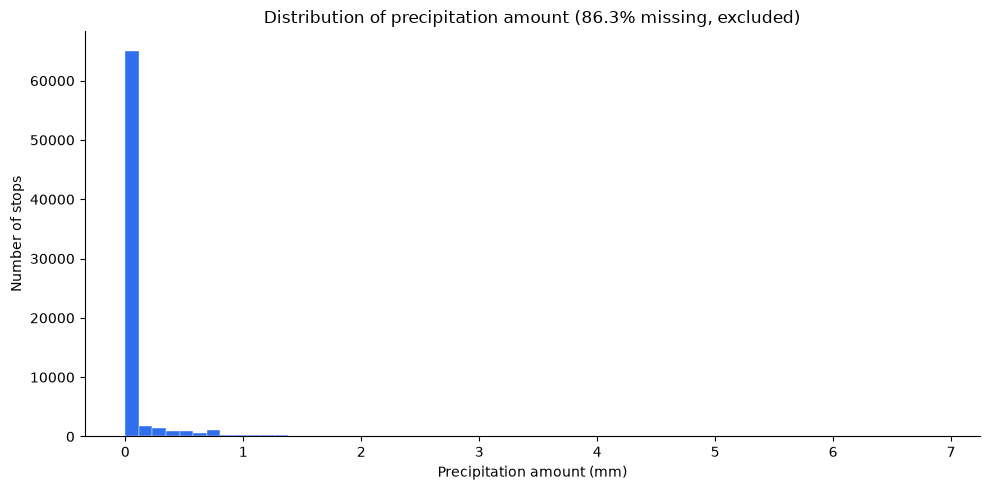

In [46]:
#plot the distribution of precipitation amount 
precip = df['Precipitation amount']
missing_share = precip.isna().mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(precip.dropna(), bins=60, color='#2F6FED', edgecolor='white', linewidth=0.3)
ax.set_title(f'Distribution of precipitation amount ({missing_share:.1f}% missing, excluded)')
ax.set_xlabel('Precipitation amount (mm)')
ax.set_ylabel('Number of stops')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [47]:
precip = df['Precipitation amount']

print(f"Exactly 0.0: {(precip == 0).sum():,} ({(precip == 0).mean()*100:.1f}%)")
print(f"Non-null and non-zero: {((precip.notna()) & (precip != 0)).sum():,}")
print()
print("Null values:")
print(f"Total null values: {precip.isna().sum():,} ({precip.isna().mean()*100:.1f}%)")
print()
print("Top 10 most common non-null values:")
print(precip.value_counts(dropna=True).head(10))

Exactly 0.0: 61,291 (11.4%)
Non-null and non-zero: 12,451

Null values:
Total null values: 463,982 (86.3%)

Top 10 most common non-null values:
Precipitation amount
0.0    61291
0.1     3775
0.2     1840
0.3     1374
0.4      954
0.5      905
0.7      592
0.6      566
0.8      429
1.0      315
Name: count, dtype: int64


As we can see the missing values do not mean that there was 0 mm of precipitation. They are missing values and the whole column should be deleted because most of the data is missing (86%).

---

## Data Preparation

We will now proceed to select only the necessary columns needed for training and cleaning the data from selected features. 

We decided to use the following features for training:

- `stationShortCode` - the station, used for grouping/clustering
- `scheduledTime` - used to derive month/season and hour-of-day features
- `differenceInMinutes` - the target variable (delay)
- `causes` - official delay cause codes, used to check whether weather is ever recorded as a cause
- `Air temperature`
- `Wind speed`
- `Relative humidity`
- `Precipitation intensity`
- `Snow depth`
- `Pressure (msl)`
- `Horizontal visibility`
- `Cloud amount`
- `Present weather (auto)` - coded weather phenomenon observed at the time of the stop

We dropped the 12h/24h/72h rolling-window aggregates since we only need the instantaneous observations, `Precipitation amount` (86% missing), `Dew-point temperature`, `Wind direction` and `Gust speed`, and all operational/administrative columns not related to weather or delay such as train numbers, operator codes, timetable metadata, etc.

In [48]:
selected_cols = [
    'stationShortCode',
    'scheduledTime',
    'differenceInMinutes',
    'causes',
    'trainStopping',
    'Air temperature',
    'Wind speed',
    'Relative humidity',
    'Precipitation intensity',
    'Snow depth',
    'Pressure (msl)',
    'Horizontal visibility',
    'Cloud amount',
    'Present weather (auto)',
]

#read only the selected columns directly from the parquet file (columnar format, so this skips loading the rest)
df_selected = pd.read_parquet(file, columns=selected_cols)

#downcast floats to save memory, and turn the repeat-heavy station code into a category
float_cols = df_selected.select_dtypes(include='float64').columns
df_selected[float_cols] = df_selected[float_cols].astype('float32')
df_selected['stationShortCode'] = df_selected['stationShortCode'].astype('category')

After extracting only the columns we need and downcasting, we are able to import the whole 96 months of data to our system.

In [49]:
import time

#load every monthly parquet file from 2018-01 to 2025-12, keeping only the selected columns
months = pd.period_range('2018-01', '2025-12', freq='M')
frames = []
failed = []

start = time.time()
for period in months:
    month_file = Path(path) / f"matched_data_flat_{period.strftime('%Y_%m')}.parquet"
    try:
        month_df = pd.read_parquet(month_file, columns=selected_cols)
    except Exception as e:
        failed.append((month_file.name, str(e)))
        continue

    float_cols = month_df.select_dtypes(include='float64').columns
    month_df[float_cols] = month_df[float_cols].astype('float32')
    month_df['stationShortCode'] = month_df['stationShortCode'].astype('category')
    month_df['causes'] = month_df['causes'].astype('category')
    frames.append(month_df)

df_all = pd.concat(frames, ignore_index=True)
df_all['stationShortCode'] = df_all['stationShortCode'].astype('category')
df_all['causes'] = df_all['causes'].astype('category')

elapsed = time.time() - start
print(f"Loaded {len(frames)}/{len(months)} months in {elapsed:.1f}s")
if failed:
    print("Failed months:")
    for name, err in failed:
        print(f"  {name}: {err}")

print(f"Rows: {len(df_all):,}")
print(f"Columns: {len(df_all.columns)}")
print(f"Memory: {df_all.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

df_all.describe(include='all')

Loaded 96/96 months in 8.2s
Rows: 47,956,194
Columns: 14
Memory: 3.44 GB


,stationShortCode,scheduledTime,differenceInMinutes,causes,trainStopping,Air temperature,Wind speed,Relative humidity,Precipitation intensity,Snow depth,Pressure (msl),Horizontal visibility,Cloud amount,Present weather (auto)
count,47956194,47956194,4.743210e+07,47956194,47956194,4.794273e+07,4.793354e+07,4.794273e+07,4.671124e+07,4.656335e+07,4.794189e+07,4.793717e+07,4.776361e+07,4.793414e+07
unique,553,8947002,NaN,255,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,PSL,2019-02-24T17:38:00.000Z,NaN,[],False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,646075,36,NaN,47409857,37579076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,3.736408e+00,NaN,NaN,6.484986e+00,3.802288e+00,7.766042e+01,7.718372e-02,7.682606e+00,1.011625e+03,3.610370e+04,4.898395e+00,1.613681e+01
std,NaN,NaN,1.350311e+01,NaN,NaN,9.989645e+00,2.140898e+00,1.934145e+01,6.088824e-01,1.542015e+01,1.169856e+01,1.984193e+04,3.422856e+00,2.849657e+01
min,NaN,NaN,-6.950000e+02,NaN,NaN,-3.920000e+01,0.000000e+00,4.000000e+00,0.000000e+00,-1.000000e+00,9.467000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,0.000000e+00,NaN,NaN,-3.000000e-01,2.300000e+00,6.500000e+01,0.000000e+00,-1.000000e+00,1.004600e+03,2.000000e+04,0.000000e+00,0.000000e+00
50%,NaN,NaN,1.000000e+00,NaN,NaN,5.700000e+00,3.500000e+00,8.400000e+01,0.000000e+00,0.000000e+00,1.012300e+03,4.017000e+04,7.000000e+00,0.000000e+00
75%,NaN,NaN,3.000000e+00,NaN,NaN,1.450000e+01,5.000000e+00,9.300000e+01,0.000000e+00,1.000000e+01,1.019400e+03,5.000000e+04,8.000000e+00,2.200000e+01


The features look all to be natural and no outliers were found. Next we check for null data.

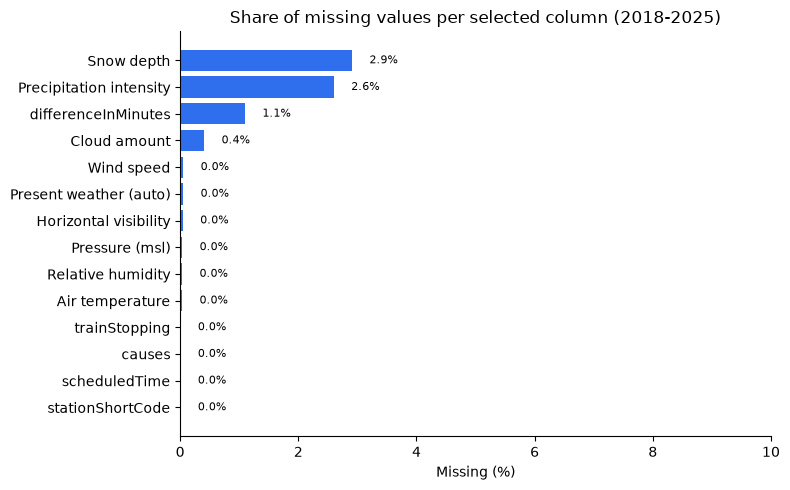

In [50]:
#share of missing values per selected column, across the full 2018-2025 dataset
missing_pct = (df_all.isna().mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(missing_pct.index, missing_pct.values, color='#2F6FED')
for y, v in enumerate(missing_pct.values):
    ax.text(v + 0.3, y, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, max(10, missing_pct.max() * 1.15))
ax.set_xlabel('Missing (%)')
ax.set_title('Share of missing values per selected column (2018-2025)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [51]:
#share of rows that have at least one missing value across the selected columns
rows_with_missing = df_all.isna().any(axis=1).mean() * 100
print(f"Rows with at least one missing value: {rows_with_missing:.1f}%")

Rows with at least one missing value: 4.4%


We decided to delete rows with missing data because predicting or replacing the missing values with the mean for weather features can skew the data.


In [52]:
#drop rows with any missing values across the selected columns
rows_before = len(df_all)
df_all = df_all.dropna().reset_index(drop=True)
rows_after = len(df_all)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Dropped:     {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before * 100:.1f}%)")

Rows before: 47,956,194
Rows after:  45,840,835
Dropped:     2,115,359 (4.4%)


Non-stopping records make up a large share of rows at low-traffic station codes and have no real delay experienced by passengers there. We filtered `df_all` to `trainStopping == True` so only genuine stops remain. We filtered out the rows where a train did not stop, as it is not necessary to calculate the delay experienced by passengers there. By keeping only the rows where a train actually stopped, we can more confidently say that this is the delay experienced by passengers.

In [53]:
#keep only rows where the train actually stopped, and drop the now-unneeded column
rows_before = len(df_all)
df_all = df_all[df_all['trainStopping']].drop(columns='trainStopping').reset_index(drop=True)
df_all['stationShortCode'] = df_all['stationShortCode'].cat.remove_unused_categories()
rows_after = len(df_all)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Dropped:     {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before * 100:.1f}%)")
print(f"Stations remaining: {df_all['stationShortCode'].nunique()}")

Rows before: 45,840,835
Rows after:  10,085,056
Dropped:     35,755,779 (78.0%)
Stations remaining: 498


### Station-level aggregation

We group all the data by `stationShortCode` and calculate the mean of every feature to prepare the data for K-means. We then mark each delay with a mask for example, if a delay happened when it was freezing, we set the reason as freezing and combine all of them to calculate the mean.

In [54]:
import numpy as np

#overall per-station delay and weather averages. Delay uses the median, not the mean - delay is
#heavily right-skewed, so a small sample's mean can be wrecked by a single extreme event
station_features = (
    df_all
    .groupby('stationShortCode', observed=True)
    .agg(
        stop_count=('differenceInMinutes', 'size'),
        median_delay=('differenceInMinutes', 'median'),
        mean_air_temperature=('Air temperature', 'mean'),
        mean_wind_speed=('Wind speed', 'mean'),
        mean_relative_humidity=('Relative humidity', 'mean'),
        mean_precipitation_intensity=('Precipitation intensity', 'mean'),
        mean_snow_depth=('Snow depth', 'mean'),
        mean_pressure=('Pressure (msl)', 'mean'),
        mean_horizontal_visibility=('Horizontal visibility', 'mean'),
        mean_cloud_amount=('Cloud amount', 'mean'),
    )
    .reset_index()
)

#median delay per station, split by weather condition, to capture weather-specific vulnerability.
#a condition built from fewer than MIN_CONDITION_STOPS stops is blanked out - too small a sample to
#trust, and prone to being skewed by a single extreme delay event
MIN_CONDITION_STOPS = 30

rain_mask = df_all['Precipitation intensity'] > 0
freezing_mask = df_all['Air temperature'] < 0
snow_mask = df_all['Snow depth'] > 0

def delay_by_station(mask, name):
    grouped = df_all[mask].groupby('stationShortCode', observed=True)['differenceInMinutes']
    result = grouped.agg(**{name: 'median', f'{name}_n': 'size'}).reset_index()
    result.loc[result[f'{name}_n'] < MIN_CONDITION_STOPS, name] = np.nan
    return result.drop(columns=f'{name}_n')

condition_masks = [
    (rain_mask, 'median_delay_rain'),
    (freezing_mask, 'median_delay_freezing'),
    (snow_mask, 'median_delay_snow'),
]

for mask, name in condition_masks:
    station_features = station_features.merge(delay_by_station(mask, name), on='stationShortCode', how='left')

print(f"Stations: {len(station_features)}")
station_features.sort_values('stop_count', ascending=False).head(10)

Stations: 498


,stationShortCode,stop_count,median_delay,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount,median_delay_rain,median_delay_freezing,median_delay_snow
321,PSL,626003,1.0,8.024979,4.517213,75.808861,0.085094,5.128417,1012.234985,33627.445312,4.397910,1.0,1.0,1.0
411,TKL,493452,1.0,7.758913,3.650258,76.047012,0.088840,5.447055,1012.228760,32356.017578,4.885032,1.0,1.0,1.0
425,TPE,415656,1.0,6.598319,4.997733,77.923706,0.074334,6.735493,1011.433289,37765.242188,5.085330,1.0,1.0,1.0
31,HKI,320279,1.0,8.073800,4.115322,75.550797,0.076844,2.861880,1012.305481,34045.898438,4.433775,1.0,1.0,1.0
416,TL,246059,1.0,6.698283,3.391140,79.579224,0.068624,5.528963,1011.674927,43330.199219,5.058011,1.0,1.0,1.0
378,SK,220664,1.0,5.621456,3.125902,79.247185,0.073758,5.937004,1010.927185,42463.097656,4.932291,1.0,1.0,1.0
170,KV,200415,1.0,6.705884,3.899909,75.389053,0.079938,6.349370,1011.905884,45550.636719,5.118494,2.0,1.0,2.0
347,RI,181733,1.0,6.657939,2.737521,80.396095,0.085339,7.340863,1012.163452,30934.925781,5.004127,1.0,1.0,1.0
35,HL,180226,1.0,6.753923,3.509696,77.229759,0.066158,5.859482,1011.552368,33534.035156,4.842143,1.0,1.0,1.0
187,LH,178010,1.0,7.056710,3.642239,74.927719,0.076019,7.593556,1011.980469,30028.621094,5.100663,2.0,2.0,2.0


In [55]:
#check whether the dropped NaN stations are just low-traffic ones or something worth worrying about
condition_cols = ['median_delay_rain', 'median_delay_freezing', 'median_delay_snow']
has_nan = station_features[condition_cols].isna().any(axis=1)

print(f"Stations with at least one NaN condition-delay: {has_nan.sum()} / {len(station_features)}")
print()
print("stop_count for stations WITH NaNs:")
print(station_features.loc[has_nan, 'stop_count'].describe())
print()
print("stop_count for stations WITHOUT NaNs:")
print(station_features.loc[~has_nan, 'stop_count'].describe())
print()
print("Highest-traffic stations that still have a NaN :")
station_features.loc[has_nan].sort_values('stop_count', ascending=False).head(10)

Stations with at least one NaN condition-delay: 268 / 498

stop_count for stations WITH NaNs:
count     268.000000
mean       71.817164
std       189.824520
min         1.000000
25%         4.000000
50%        12.000000
75%        64.250000
max      2365.000000
Name: stop_count, dtype: float64

stop_count for stations WITHOUT NaNs:
count       230.000000
mean      43764.386957
std       72067.167038
min         230.000000
25%        5600.250000
50%       22223.000000
75%       54137.000000
max      626003.000000
Name: stop_count, dtype: float64

Highest-traffic stations that still have a NaN :


,stationShortCode,stop_count,median_delay,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount,median_delay_rain,median_delay_freezing,median_delay_snow
36,HLS,2365,3.0,16.365961,4.054334,63.816067,0.079450,-0.652854,1013.126526,58877.820312,4.123044,3.0,2.0,NaN
66,IKO,1393,2.0,18.994759,5.727925,74.862885,0.122111,-0.292175,1013.483948,38615.335938,3.077531,6.0,NaN,14.0
301,PKU,601,2.0,10.586356,5.536439,84.176376,0.039434,4.164725,1013.727661,33686.015625,3.074875,NaN,2.0,2.0
93,JSK,520,0.0,5.081923,3.054808,82.634613,0.050962,8.686539,1010.675964,44580.578125,5.169231,NaN,0.0,0.0
147,KRM,432,-2.0,7.174074,2.448611,78.733795,0.045370,7.247685,1012.373108,38557.082031,4.328704,NaN,-5.0,-6.0
326,PTL,390,0.0,2.636410,3.742308,87.966667,0.116923,-0.079487,1009.233093,30562.251953,5.871795,0.0,0.0,NaN
441,TVE,388,0.0,3.470618,3.613917,90.871132,0.057216,-0.061856,1008.942261,30926.958984,5.463918,NaN,0.0,NaN
401,SUO,374,0.0,10.713903,3.365776,72.403740,0.096257,1.101604,1012.212585,42869.035156,4.847594,NaN,2.0,0.5
262,NLÄ,371,0.0,14.523719,4.599461,68.884094,0.153908,0.633423,1012.551453,49392.875000,4.719676,0.0,NaN,0.0
419,TMU,353,-1.0,8.167422,2.818697,74.864021,0.094901,7.322946,1011.405090,36412.085938,4.422096,NaN,0.0,0.0


This justifies our reason to drop all stations with NaN values, as they have too few stops to make any good predictions.

#### Scaling and dropping small stations with NaN's

After verifying that most of the stations with NaN values are with little traffic. We decided to drop all of them and after that standardize the data and prepare it for K-means.



In [56]:
from sklearn.preprocessing import StandardScaler

#drop any station still carrying a NaN (StandardScaler can't handle them) before scaling
station_features_clean = station_features.dropna().reset_index(drop=True)
print(f"Stations: {len(station_features)} -> {len(station_features_clean)} after dropping remaining NaNs")

#use delay EXCESS relative to each station's own baseline, instead of the raw condition delays -
#those were ~0.9 correlated with the baseline delay (and with each other), so clustering mostly
#picked up "how delay-prone is this station overall" rather than weather-specific sensitivity
station_features_clean['excess_delay_rain'] = station_features_clean['median_delay_rain'] - station_features_clean['median_delay']
station_features_clean['excess_delay_freezing'] = station_features_clean['median_delay_freezing'] - station_features_clean['median_delay']
station_features_clean['excess_delay_snow'] = station_features_clean['median_delay_snow'] - station_features_clean['median_delay']

cluster_cols = [
    'median_delay',
    'mean_air_temperature',
    'mean_wind_speed',
    'mean_relative_humidity',
    'mean_precipitation_intensity',
    'mean_snow_depth',
    'mean_pressure',
    'mean_horizontal_visibility',
    'mean_cloud_amount',
    'excess_delay_rain',
    'excess_delay_freezing',
    'excess_delay_snow',
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(station_features_clean[cluster_cols])

scaled_df = pd.DataFrame(scaled_features, columns=cluster_cols, index=station_features_clean['stationShortCode'])
scaled_df.head(30)

Stations: 498 -> 230 after dropping remaining NaNs


,median_delay,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount,excess_delay_rain,excess_delay_freezing,excess_delay_snow
stationShortCode,,,,,,,,,,,,
AHO,-1.372439,-3.611366,0.102900,1.984484,-0.654227,-0.533909,-7.977318,0.464944,0.605122,-1.748218,-0.282485,-0.198835
AHV,-0.598760,1.192428,0.172412,-2.059968,-1.439304,-1.293587,0.311193,-0.353515,-0.465484,-0.449058,-0.282485,-0.198835
ALV,-0.598760,-0.214257,-0.765307,0.855126,-0.105297,0.014004,0.015612,-2.048048,0.630930,-0.449058,-0.282485,-0.198835
APT,0.948597,-0.362686,-0.405907,0.261344,0.270579,0.650927,-0.214450,1.309146,1.181367,-0.449058,-0.282485,-0.198835
DRA,0.174919,0.867415,3.166451,1.087713,-0.461969,-1.445239,0.962720,-0.248005,-2.929321,-0.449058,-0.282485,-0.198835
ENO,-0.598760,0.197840,-0.054620,-1.118118,0.235472,0.530762,0.424390,0.936226,1.041474,-0.449058,-0.282485,-0.198835
EPZ,-0.598760,0.171598,-0.841254,-0.107522,-0.254549,0.125790,0.108241,-1.930867,0.515960,-0.449058,-0.282485,-0.198835
ERV,0.948597,3.002712,-0.026657,-1.892278,0.123306,-1.351377,0.954493,-0.419806,-1.017593,0.200523,-0.282485,-1.215102
HD,-0.598760,-1.257432,1.116017,1.167075,-0.330499,0.307486,-0.974664,-1.511695,-0.166336,-0.449058,-0.282485,-0.198835


## Modeling

After succesfully preparing the data we proceed to create the model. The first step is to find the right K-value. We decided to use the elbow-method to find the right K-Value. For training and predicting the model we use Sklearn's library.

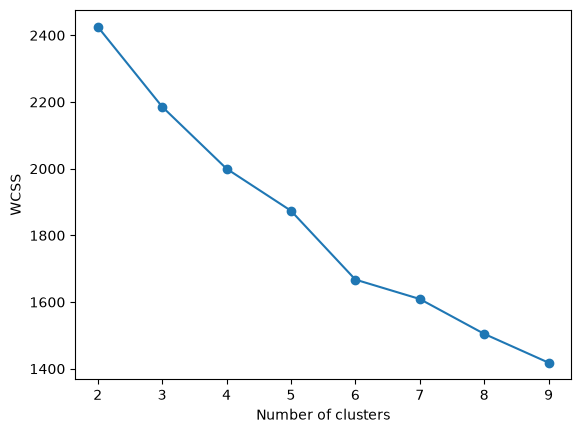

In [59]:
from sklearn.cluster import KMeans

#determine the optimal number of clusters using the elbow method
wcss = []
for i in range(2,10):
    model = KMeans(init='random', n_clusters=i, random_state=40).fit(scaled_df)
    wcss.append(model.inertia_)
    
plt.plot(range(2,10), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

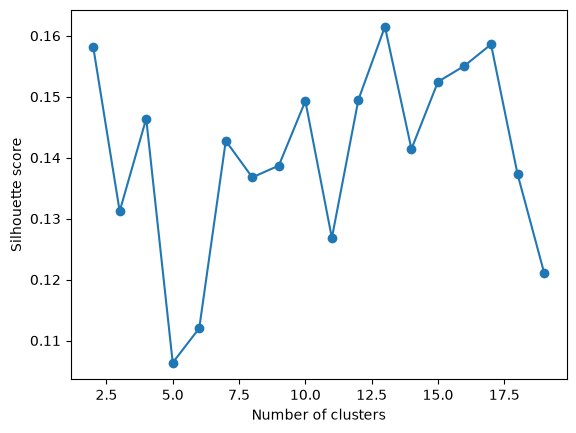

In [58]:
from sklearn.metrics import silhouette_score

#silhouette score alongside the elbow method - the elbow can be ambiguous on its own, silhouette tells us how well-separated the clusters actually are
silhouette_scores = []
for i in range(2, 20):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(scaled_df)
    silhouette_scores.append(silhouette_score(scaled_df, model.labels_))

plt.plot(range(2, 20), silhouette_scores, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

The elbow plot flattens noticeably from k=6 onward, but k=5 and k=6 are local dips in the silhouette plot rather than improvements. We pick **k=4**: it sits right before that dip, has a solid silhouette score, is past the steepest part of the WCSS drop, and keeps the clusters small enough to be interpretable.

In [62]:
#fit the final model with the chosen k and assign a cluster label back to each station
K = 4
final_model = KMeans(n_clusters=K, init='random', random_state=42, n_init=10).fit(scaled_df)
station_features_clean['cluster'] = final_model.labels_

print(station_features_clean['cluster'].value_counts().sort_index())
print()

#mean of each clustering feature per cluster, to see what distinguishes them
station_features_clean.groupby('cluster')[cluster_cols].mean()

cluster
0     40
1     49
2     30
3    111
Name: count, dtype: int64



,median_delay,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount,excess_delay_rain,excess_delay_freezing,excess_delay_snow
cluster,,,,,,,,,,,,
0,0.850000,7.767852,4.683998,77.327530,0.074579,4.183818,1011.921875,35261.546875,4.533416,0.037500,-0.212500,-0.237500
1,1.081633,5.849218,3.829474,78.089012,0.079018,9.002375,1011.162170,39780.863281,4.904835,1.275510,1.204082,1.071429
2,0.466667,1.943276,3.594254,82.456535,0.064761,17.366405,1009.330627,34648.152344,4.852760,0.250000,0.166667,0.100000
3,0.693694,5.723345,3.407107,78.006783,0.072624,10.514428,1011.508789,33280.773438,5.034925,0.072072,-0.009009,-0.009009
